# Probabilistic Calibration and Proper Scoring Rules

This notebook provides a comprehensive introduction to:
- Proper scoring rules for evaluating probabilistic classifiers
- Reliability diagrams and Expected Calibration Error (ECE)
- Calibration methods: Platt scaling, isotonic regression, and temperature scaling
- Applications to image classification, object detection, and LLM confidence calibration

---

## Learning Objectives

By the end of this notebook, you will be able to:
1. Explain the difference between discrimination and calibration
2. Implement and interpret proper scoring rules (NLL, Brier score)
3. Create reliability diagrams and compute ECE
4. Apply post-hoc calibration methods to improve model calibration
5. Adapt these techniques to your own model outputs

In [1]:
# Standard imports and reproducibility setup
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
rng = np.random.default_rng(RANDOM_SEED)

# Plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['legend.fontsize'] = 10

OUT_DIR = "."

print("Setup complete. Random seed:", RANDOM_SEED)

Setup complete. Random seed: 42


---

# Part 1: Proper Scoring Rules for Classification

## What is Calibration?

A **probabilistic classifier** outputs probabilities (confidence scores) for each class. A classifier is said to be **well-calibrated** if these probabilities reflect the true likelihood of correctness.

**Example:** If a model predicts class A with 80% confidence across 100 samples, approximately 80 of those predictions should actually be correct.

## Why Does Calibration Matter?

- **Decision making under uncertainty**: Medical diagnosis, autonomous vehicles
- **Combining multiple models**: Ensemble methods rely on calibrated probabilities
- **Risk assessment**: Finance, insurance, safety-critical systems
- **Selective prediction**: Knowing when to abstain or defer to humans

## Proper Scoring Rules

A **proper scoring rule** is a function that measures the quality of probabilistic predictions. It is "proper" if the expected score is optimized when the predicted probabilities equal the true probabilities.

The two most common proper scoring rules are:

### 1. Negative Log-Likelihood (NLL) / Cross-Entropy Loss

$$\text{NLL} = -\frac{1}{N}\sum_{i=1}^{N} \log(p_{y_i})$$

where $p_{y_i}$ is the predicted probability for the true class $y_i$.

**Properties:**
- Heavily penalizes confident wrong predictions
- Range: $[0, \infty)$, lower is better

### 2. Brier Score

$$\text{Brier} = \frac{1}{N}\sum_{i=1}^{N} (p_i - y_i)^2$$

**Properties:**
- Measures squared error between predictions and one-hot labels
- Range: $[0, 1]$ for binary
- Less sensitive to confident wrong predictions than NLL

In [2]:
# Implementation of proper scoring rules

def compute_nll(y_true, y_prob, eps=1e-15):
    """
    Compute Negative Log-Likelihood (cross-entropy loss).
    
    Parameters:
    -----------
    y_true : array-like of shape (n_samples,)
        True class labels (integers)
    y_prob : array-like of shape (n_samples, n_classes) or (n_samples,)
        Predicted probabilities. For binary, can be 1D (prob of positive class)
    eps : float
        Small constant to avoid log(0)
    
    Returns:
    --------
    float : Mean negative log-likelihood
    """
    y_prob = np.asarray(y_prob)
    y_true = np.asarray(y_true)
    
    # Handle binary case
    if y_prob.ndim == 1:
        y_prob = np.column_stack([1 - y_prob, y_prob])
    
    # Clip probabilities to avoid log(0)
    y_prob = np.clip(y_prob, eps, 1 - eps)
    
    # Get probability of true class for each sample
    n_samples = len(y_true)
    true_class_probs = y_prob[np.arange(n_samples), y_true.astype(int)]
    
    return -np.mean(np.log(true_class_probs))


def compute_brier_score(y_true, y_prob):
    """
    Compute Brier Score.
    
    Parameters:
    -----------
    y_true : array-like of shape (n_samples,)
        True class labels
    y_prob : array-like of shape (n_samples, n_classes) or (n_samples,)
        Predicted probabilities
    
    Returns:
    --------
    float : Brier score
    """
    y_prob = np.asarray(y_prob)
    y_true = np.asarray(y_true)
    
    # Handle binary case
    if y_prob.ndim == 1:
        # Binary: Brier = mean((p - y)^2)
        return np.mean((y_prob - y_true) ** 2)
    
    # Multiclass: create one-hot encoding
    n_samples = len(y_true)
    n_classes = y_prob.shape[1]
    y_one_hot = np.zeros((n_samples, n_classes))
    y_one_hot[np.arange(n_samples), y_true.astype(int)] = 1
    
    return np.mean(np.sum((y_prob - y_one_hot) ** 2, axis=1))

## Demonstration: Proper Scoring Rules

To understand proper scoring rules, let's simulate three scenarios where a model makes predictions about a binary event with **known true probability** $q = 0.7$ (70% chance of positive class):

1. **Well-calibrated**: Model predicts $p = 0.7$ (matches the true probability)
2. **Overconfident**: Model predicts $p = 0.95$ (too confident about positive)
3. **Underconfident**: Model predicts $p = 0.55$ (too uncertain)

For proper scoring rules, the **expected score** should be optimized when $p = q$.

In [3]:
# Demonstration: Proper Scoring Rules with TRUE probability scenario
print("=" * 70)
print("Demonstration: Proper Scoring Rules")
print("=" * 70)
print("\nScenario: True probability of positive class q = 0.7")
print("We generate outcomes from this true distribution and compare predictions.\n")

n_samples = 10000
q_true = 0.7  # True probability of positive class

# Generate outcomes from the true distribution
y_true_demo = rng.binomial(1, q_true, n_samples)

# Three prediction scenarios (constant predictions for all samples)
# 1. Well-calibrated: predicts p = 0.7 (matches true probability)
p_well_calibrated = np.full(n_samples, 0.7)

# 2. Overconfident: predicts p = 0.95 (too confident about positive)
p_overconfident = np.full(n_samples, 0.95)

# 3. Underconfident: predicts p = 0.55 (too uncertain, closer to 0.5)
p_underconfident = np.full(n_samples, 0.55)

print("Scenario 1: Well-calibrated (predicts p = 0.7)")
print(f"  NLL:   {compute_nll(y_true_demo, p_well_calibrated):.4f}")
print(f"  Brier: {compute_brier_score(y_true_demo, p_well_calibrated):.4f}")

print("\nScenario 2: Overconfident (predicts p = 0.95)")
print(f"  NLL:   {compute_nll(y_true_demo, p_overconfident):.4f}")
print(f"  Brier: {compute_brier_score(y_true_demo, p_overconfident):.4f}")

print("\nScenario 3: Underconfident (predicts p = 0.55)")
print(f"  NLL:   {compute_nll(y_true_demo, p_underconfident):.4f}")
print(f"  Brier: {compute_brier_score(y_true_demo, p_underconfident):.4f}")

print("\n" + "="*70)
print("Key Insight:")
print("- Well-calibrated predictions (p=0.7) achieve the BEST scores")
print("- Overconfident (p=0.95) is penalized for the 30% negatives it predicted wrong")
print("- Underconfident (p=0.55) is penalized for not being confident enough")
print("- NLL penalizes overconfidence MORE heavily than Brier score")
print("="*70)

Demonstration: Proper Scoring Rules

Scenario: True probability of positive class q = 0.7
We generate outcomes from this true distribution and compare predictions.

Scenario 1: Well-calibrated (predicts p = 0.7)
  NLL:   0.6059
  Brier: 0.2077

Scenario 2: Overconfident (predicts p = 0.95)
  NLL:   0.9175
  Brier: 0.2673

Scenario 3: Underconfident (predicts p = 0.55)
  NLL:   0.6569
  Brier: 0.2319

Key Insight:
- Well-calibrated predictions (p=0.7) achieve the BEST scores
- Overconfident (p=0.95) is penalized for the 30% negatives it predicted wrong
- Underconfident (p=0.55) is penalized for not being confident enough
- NLL penalizes overconfidence MORE heavily than Brier score


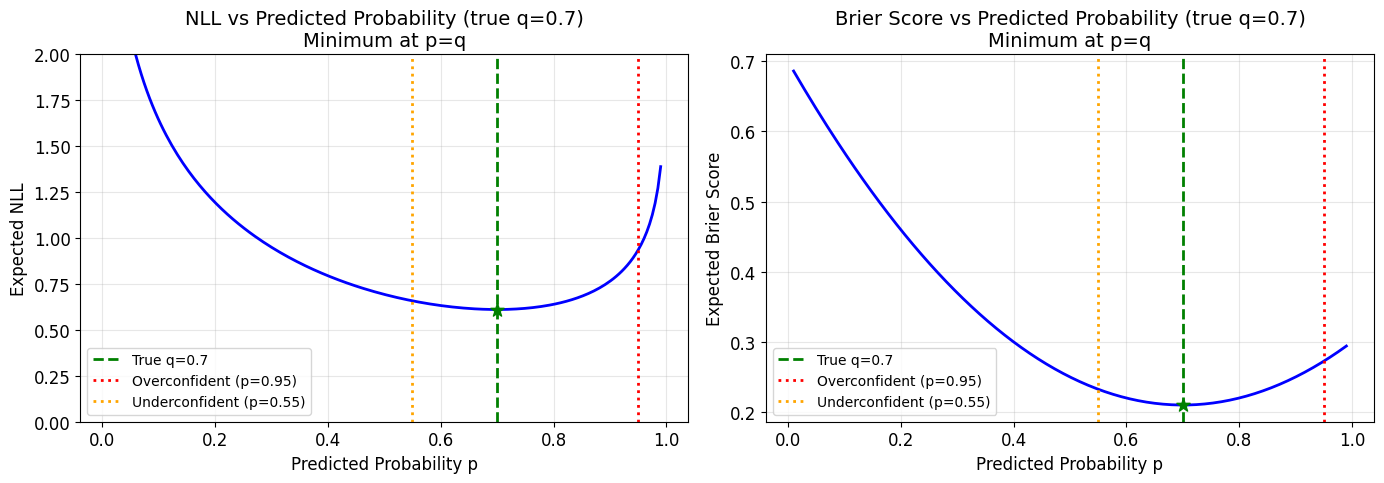


Saved: proper_scores_nll_brier.png


In [4]:
# Visualize: How NLL and Brier change as predicted probability varies
# when the true probability is q = 0.7

q_true = 0.7
p_range = np.linspace(0.01, 0.99, 200)

# Expected NLL: -[q*log(p) + (1-q)*log(1-p)]
expected_nll = -(q_true * np.log(p_range) + (1 - q_true) * np.log(1 - p_range))

# Expected Brier: q*(1-p)^2 + (1-q)*p^2
expected_brier = q_true * (1 - p_range)**2 + (1 - q_true) * p_range**2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# NLL plot
ax = axes[0]
ax.plot(p_range, expected_nll, 'b-', linewidth=2)
ax.axvline(x=q_true, color='g', linestyle='--', linewidth=2, label=f'True q={q_true}')
ax.axvline(x=0.95, color='r', linestyle=':', linewidth=2, label='Overconfident (p=0.95)')
ax.axvline(x=0.55, color='orange', linestyle=':', linewidth=2, label='Underconfident (p=0.55)')
ax.scatter([q_true], [-(q_true * np.log(q_true) + (1 - q_true) * np.log(1 - q_true))], 
           s=100, c='green', zorder=5, marker='*')
ax.set_xlabel('Predicted Probability p')
ax.set_ylabel('Expected NLL')
ax.set_title('NLL vs Predicted Probability (true q=0.7)\nMinimum at p=q')
ax.legend()
ax.grid(True, alpha=0.3)
ax.set_ylim(0, 2)

# Brier plot
ax = axes[1]
ax.plot(p_range, expected_brier, 'b-', linewidth=2)
ax.axvline(x=q_true, color='g', linestyle='--', linewidth=2, label=f'True q={q_true}')
ax.axvline(x=0.95, color='r', linestyle=':', linewidth=2, label='Overconfident (p=0.95)')
ax.axvline(x=0.55, color='orange', linestyle=':', linewidth=2, label='Underconfident (p=0.55)')
ax.scatter([q_true], [q_true * (1 - q_true)**2 + (1 - q_true) * q_true**2], 
           s=100, c='green', zorder=5, marker='*')
ax.set_xlabel('Predicted Probability p')
ax.set_ylabel('Expected Brier Score')
ax.set_title('Brier Score vs Predicted Probability (true q=0.7)\nMinimum at p=q')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/proper_scores_nll_brier.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: proper_scores_nll_brier.png")

---

# Part 2: Reliability Diagrams and Expected Calibration Error (ECE)

## Reliability Diagrams

A **reliability diagram** (calibration curve) visualizes how well-calibrated a model is:
- X-axis: Mean predicted probability in each bin
- Y-axis: Fraction of positives (actual accuracy) in each bin

A perfectly calibrated model follows the diagonal line (y = x).

**Interpretation:**
- **Overconfident**: Curve is BELOW the diagonal (predicted probability > actual accuracy)
- **Underconfident**: Curve is ABOVE the diagonal (predicted probability < actual accuracy)

## Expected Calibration Error (ECE)

ECE quantifies the calibration error as a weighted average of bin-wise calibration errors:

$$\text{ECE} = \sum_{m=1}^{M} \frac{|B_m|}{N} |\text{acc}(B_m) - \text{conf}(B_m)|$$

In [5]:
from sklearn.calibration import calibration_curve

def ece_binary(probs, y_true, n_bins=10):
    """ECE for binary classification using predicted prob for class 1."""
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)
    bins = np.linspace(0.0, 1.0, n_bins+1)
    ece = 0.0
    for i in range(n_bins):
        lo, hi = bins[i], bins[i+1]
        mask = (probs >= lo) & (probs < hi) if i < n_bins-1 else (probs >= lo) & (probs <= hi)
        if mask.sum() == 0:
            continue
        acc = y_true[mask].mean()
        conf = probs[mask].mean()
        ece += (mask.sum()/len(probs))*abs(acc-conf)
    return float(ece)

def compute_calibration_curve(y_true, y_prob, n_bins=10, strategy='uniform'):
    """
    Compute calibration curve data for reliability diagrams.
    """
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    
    if strategy == 'uniform':
        bin_edges = np.linspace(0, 1, n_bins + 1)
    elif strategy == 'quantile':
        quantiles = np.linspace(0, 100, n_bins + 1)
        bin_edges = np.percentile(y_prob, quantiles)
        bin_edges[0] = 0.0
        bin_edges[-1] = 1.0
    else:
        raise ValueError(f"Unknown strategy: {strategy}")
    
    bin_centers = []
    bin_accuracies = []
    bin_counts = []
    
    for i in range(n_bins):
        if i == n_bins - 1:
            mask = (y_prob >= bin_edges[i]) & (y_prob <= bin_edges[i+1])
        else:
            mask = (y_prob >= bin_edges[i]) & (y_prob < bin_edges[i+1])
        
        if np.sum(mask) > 0:
            bin_centers.append(np.mean(y_prob[mask]))
            bin_accuracies.append(np.mean(y_true[mask]))
            bin_counts.append(np.sum(mask))
        else:
            bin_centers.append((bin_edges[i] + bin_edges[i+1]) / 2)
            bin_accuracies.append(np.nan)
            bin_counts.append(0)
    
    bin_centers = np.array(bin_centers)
    bin_accuracies = np.array(bin_accuracies)
    bin_counts = np.array(bin_counts)
    
    # Compute ECE (ignoring empty bins)
    n_samples = len(y_true)
    valid_mask = ~np.isnan(bin_accuracies)
    ece = np.sum(bin_counts[valid_mask] / n_samples * np.abs(bin_accuracies[valid_mask] - bin_centers[valid_mask]))
    
    return {
        'bin_edges': bin_edges,
        'bin_centers': bin_centers,
        'bin_accuracies': bin_accuracies,
        'bin_counts': bin_counts,
        'ece': ece
    }

def plot_reliability_diagram(y_true, y_prob, n_bins=10, strategy='uniform', 
                             ax=None, name=None, color=None):
    """Plot reliability diagram."""
    result = compute_calibration_curve(y_true, y_prob, n_bins, strategy)
    
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6))
    
    # Plot perfect calibration line
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration', linewidth=2)
    
    # Plot calibration curve (only non-NaN points)
    valid = ~np.isnan(result['bin_accuracies'])
    label = name if name else 'Model'
    ax.plot(result['bin_centers'][valid], result['bin_accuracies'][valid], 
            's-', markersize=8, linewidth=2, color=color, 
            label=f'{label} (ECE={result["ece"]:.3f})')
    
    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])
    ax.legend(loc='upper left')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    return result

Generating reliability diagrams for different calibration scenarios...

Key interpretation:
- OVERCONFIDENT: curve BELOW diagonal (model thinks it's better than it is)
- UNDERCONFIDENT: curve ABOVE diagonal (model is better than it thinks)


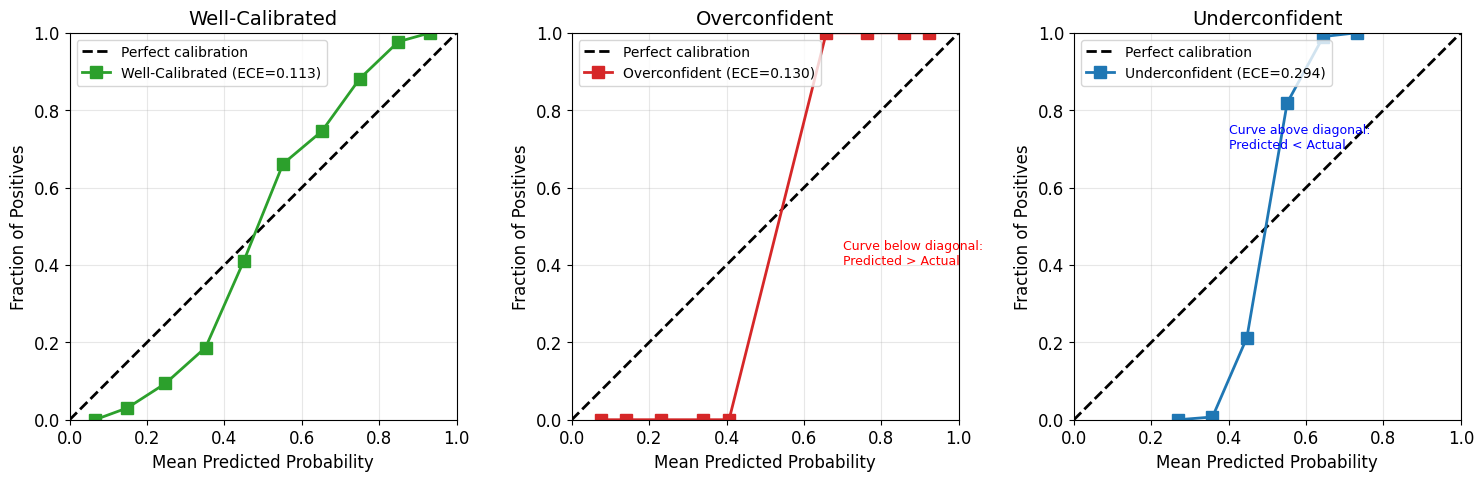


Saved: sklearn_calibration_curve.png


In [6]:
# Generate reliability diagrams demonstrating calibration patterns
print("Generating reliability diagrams for different calibration scenarios...")
print("\nKey interpretation:")
print("- OVERCONFIDENT: curve BELOW diagonal (model thinks it's better than it is)")
print("- UNDERCONFIDENT: curve ABOVE diagonal (model is better than it thinks)")

np.random.seed(RANDOM_SEED)
n = 2000

# Generate ground truth with 50% base rate
y_true_rd = np.random.binomial(1, 0.5, n)

# Scenario 1: Well-calibrated
# Logits that produce well-calibrated probabilities
logits_well = 2.0 * (y_true_rd - 0.5) + np.random.normal(0, 1, n)
p_well_calibrated = 1 / (1 + np.exp(-logits_well))

# Scenario 2: Overconfident (pushes probabilities toward extremes)
# Higher scaling factor makes predictions more extreme
logits_over = 4.0 * (y_true_rd - 0.5) + np.random.normal(0, 0.5, n)
p_overconfident = 1 / (1 + np.exp(-logits_over))

# Scenario 3: Underconfident (pushes probabilities toward 0.5)
# Lower scaling factor makes predictions less extreme
logits_under = 0.8 * (y_true_rd - 0.5) + np.random.normal(0, 0.3, n)
p_underconfident = 1 / (1 + np.exp(-logits_under))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

scenarios = [
    (p_well_calibrated, 'Well-Calibrated', 'tab:green'),
    (p_overconfident, 'Overconfident', 'tab:red'),
    (p_underconfident, 'Underconfident', 'tab:blue')
]

for ax, (probs, title, color) in zip(axes, scenarios):
    result = plot_reliability_diagram(y_true_rd, probs, n_bins=10, ax=ax, name=title, color=color)
    ax.set_title(title)
    
    # Add annotation explaining pattern
    if 'Overconfident' in title:
        ax.annotate('Curve below diagonal:\nPredicted > Actual', 
                   xy=(0.7, 0.4), fontsize=9, color='red')
    elif 'Underconfident' in title:
        ax.annotate('Curve above diagonal:\nPredicted < Actual', 
                   xy=(0.4, 0.7), fontsize=9, color='blue')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/sklearn_calibration_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("\nSaved: sklearn_calibration_curve.png")

---

# Part 3: Calibration on Real Data - sklearn Example

Following the spirit of the sklearn calibration example, we compare:
- An uncalibrated model (LinearSVC decision scores pushed through a naive sigmoid)
- **Platt (sigmoid) calibration**
- **Isotonic regression calibration**
- **Temperature scaling**

In [7]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss, log_loss

# Load breast cancer dataset
X, y = load_breast_cancer(return_X_y=True)
print(f"Dataset: {X.shape[0]} samples, {X.shape[1]} features")

# Train / calibration / test split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=0, stratify=y)
X_cal, X_test, y_cal, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0, stratify=y_temp)

print(f"Train: {len(X_train)}, Calibration: {len(X_cal)}, Test: {len(X_test)}")

# Train base SVC
svc = LinearSVC(max_iter=10000).fit(X_train, y_train)

# Calibrate using cross-validation (works across sklearn versions)
X_train_cal = np.vstack([X_train, X_cal])
y_train_cal = np.concatenate([y_train, y_cal])

svc_sig = CalibratedClassifierCV(LinearSVC(max_iter=10000), method="sigmoid", cv=3).fit(X_train_cal, y_train_cal)
svc_iso = CalibratedClassifierCV(LinearSVC(max_iter=10000), method="isotonic", cv=3).fit(X_train_cal, y_train_cal)
svc_temperature = CalibratedClassifierCV(LinearSVC(max_iter=10000), method="temperature", cv=3).fit(X_train_cal, y_train_cal)

# Get predictions
scores = svc.decision_function(X_test)
p_naive = 1 / (1 + np.exp(-scores))  # Naive sigmoid

p_sig = svc_sig.predict_proba(X_test)[:, 1]
p_iso = svc_iso.predict_proba(X_test)[:, 1]
p_temperature = svc_temperature.predict_proba(X_test)[:, 1]

def metrics_binary(p, y):
    return {
        "NLL": float(log_loss(y, np.vstack([1-p, p]).T, labels=[0, 1])),
        "Brier": float(brier_score_loss(y, p)),
        "ECE": ece_binary(p, y, 10),
        "Acc": float(((p >= 0.5).astype(int) == y).mean()),
    }

print("\n" + "="*70)
print("Breast Cancer Dataset - Calibration Results")
print("="*70)
print(f"{'Model':<25} {'Accuracy':>10} {'NLL':>10} {'Brier':>10} {'ECE':>10}")
print("-"*70)

for name, p in [("SVC naive sigmoid", p_naive), ("SVC + Platt", p_sig), ("SVC + Isotonic", p_iso), ("SVC + Temperature", p_temperature)]:
    m = metrics_binary(p, y_test)
    print(f"{name:<25} {m['Acc']:>10.4f} {m['NLL']:>10.4f} {m['Brier']:>10.4f} {m['ECE']:>10.4f}")

Dataset: 569 samples, 30 features
Train: 341, Calibration: 114, Test: 114

Breast Cancer Dataset - Calibration Results
Model                       Accuracy        NLL      Brier        ECE
----------------------------------------------------------------------
SVC naive sigmoid             0.9737     0.1786     0.0418     0.1168
SVC + Platt                   0.9649     0.0991     0.0259     0.0355
SVC + Isotonic                0.9649     0.0733     0.0239     0.0342
SVC + Temperature             0.9649     0.0810     0.0244     0.0308


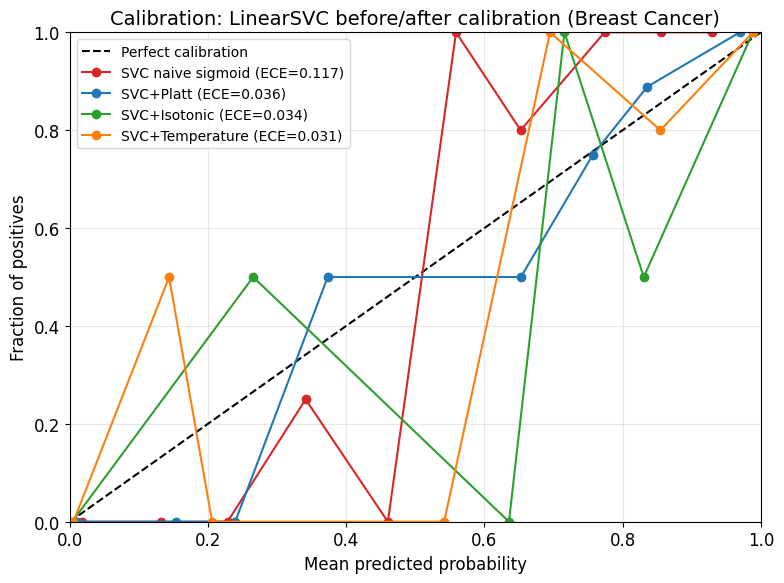

In [12]:
# Plot reliability diagrams
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color='black', label='Perfect calibration')

colors = ['tab:red', 'tab:blue', 'tab:green', 'tab:orange']
for (name, p), color in zip([("SVC naive sigmoid", p_naive), ("SVC+Platt", p_sig), ("SVC+Isotonic", p_iso), ("SVC+Temperature", p_temperature)], colors):
    frac_pos, mean_pred = calibration_curve(y_test, p, n_bins=10, strategy="uniform")
    ece = ece_binary(p, y_test, 10)
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{name} (ECE={ece:.3f})", color=color)

ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration: LinearSVC before/after calibration (Breast Cancer)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.tight_layout()
plt.savefig(f"{OUT_DIR}/breast_cancer_calibration.png", dpi=200)
plt.show()

---

# Part 4: Temperature Scaling (Multiclass)

Temperature scaling fits a single scalar **T** on a calibration set by minimizing NLL:

$$q = \text{softmax}(z / T)$$

- **T > 1**: Softens predictions (reduces confidence) - for overconfident models
- **T < 1**: Sharpens predictions (increases confidence) - for underconfident models
- Does **not** change the predicted class (argmax unchanged)

In [13]:
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from scipy.special import softmax
from scipy.optimize import minimize

# Load digits dataset
X_d, y_d = load_digits(return_X_y=True)
print(f"Digits dataset: {X_d.shape[0]} samples, {X_d.shape[1]} features, {len(np.unique(y_d))} classes")

# Split
X_train, X_temp, y_train, y_temp = train_test_split(X_d, y_d, test_size=0.4, random_state=0, stratify=y_d)
X_cal, X_test, y_cal, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=0, stratify=y_temp)

print(f"Train: {len(X_train)}, Calibration: {len(X_cal)}, Test: {len(X_test)}")

# Train logistic regression
clf = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, solver="lbfgs"))
clf.fit(X_train, y_train)

# Get logits
logits_cal = clf.decision_function(X_cal)
logits_test = clf.decision_function(X_test)

def nll_from_logits(logits, y_true, T=1.0):
    """Compute NLL for multiclass with temperature scaling."""
    probs = softmax(logits / T, axis=1)
    eps = 1e-12
    return -np.mean(np.log(probs[np.arange(len(y_true)), y_true] + eps))

# Optimize T by optimizing log(T) (unconstrained -> T > 0)
def obj(logT):
    T = np.exp(logT[0])
    return nll_from_logits(logits_cal, y_cal, T)

res = minimize(obj, x0=np.array([0.0]), method="Nelder-Mead", options={"maxiter": 200})
T_opt = float(np.exp(res.x[0]))
print(f"\nOptimal temperature: {T_opt:.4f}")
print(f"(T > 1 means model was overconfident, T < 1 means underconfident)")

Digits dataset: 1797 samples, 64 features, 10 classes
Train: 1078, Calibration: 359, Test: 360

Optimal temperature: 0.7031
(T > 1 means model was overconfident, T < 1 means underconfident)


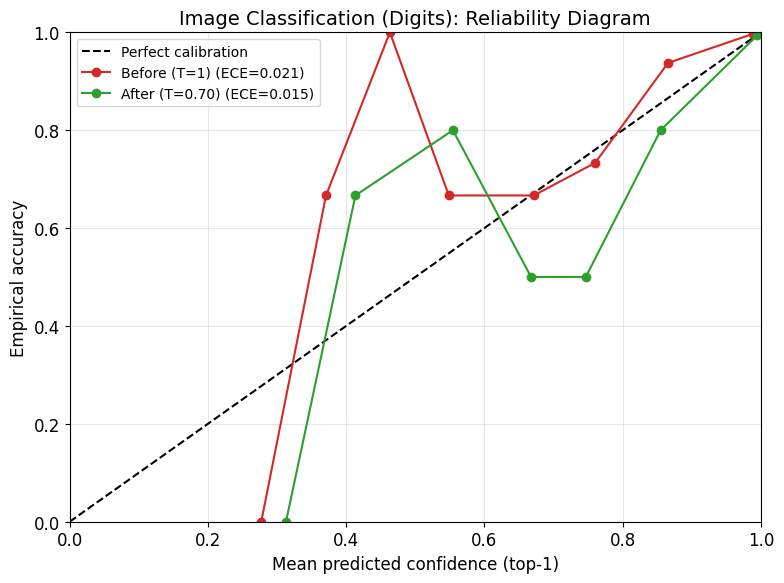


Saved: digits_temp_scaling_reliability.png


In [14]:
def top1_conf_correct(logits, y_true, T=1.0):
    """Get top-1 confidence and correctness for multiclass."""
    probs = softmax(logits / T, axis=1)
    conf = probs.max(axis=1)
    pred = probs.argmax(axis=1)
    correct = (pred == y_true).astype(int)
    return conf, correct

conf_b, corr_b = top1_conf_correct(logits_test, y_test, T=1.0)
conf_a, corr_a = top1_conf_correct(logits_test, y_test, T=T_opt)

ece_b = ece_binary(conf_b, corr_b, 10)
ece_a = ece_binary(conf_a, corr_a, 10)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color='black', label='Perfect calibration')

for name, conf, corr, color in [("Before (T=1)", conf_b, corr_b, 'tab:red'), 
                                  (f"After (T={T_opt:.2f})", conf_a, corr_a, 'tab:green')]:
    frac_pos, mean_pred = calibration_curve(corr, conf, n_bins=10, strategy="uniform")
    ece = ece_binary(conf, corr, 10)
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{name} (ECE={ece:.3f})", color=color)

ax.set_xlabel("Mean predicted confidence (top-1)")
ax.set_ylabel("Empirical accuracy")
ax.set_title("Image Classification (Digits): Reliability Diagram")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/digits_temp_scaling_reliability.png", dpi=200)
plt.show()
print("\nSaved: digits_temp_scaling_reliability.png")

In [15]:
# Print metrics comparison
print("\n" + "="*75)
print("Image Classification (Digits) - Temperature Scaling Results")
print("="*75)
print(f"{'Metric':<20} {'Before (T=1)':>20} {'After Temp Scaling':>20}")
print("-"*75)

# Accuracy (should be the same - temp scaling preserves predictions)
probs_b = softmax(logits_test / 1.0, axis=1)
probs_a = softmax(logits_test / T_opt, axis=1)
acc_b = np.mean(probs_b.argmax(axis=1) == y_test)
acc_a = np.mean(probs_a.argmax(axis=1) == y_test)
print(f"{'Accuracy':<20} {acc_b:>20.4f} {acc_a:>20.4f}")

# NLL
nll_b = compute_nll(y_test, probs_b)
nll_a = compute_nll(y_test, probs_a)
print(f"{'NLL (Log Loss)':<20} {nll_b:>20.4f} {nll_a:>20.4f}")

# Brier
brier_b = compute_brier_score(y_test, probs_b)
brier_a = compute_brier_score(y_test, probs_a)
print(f"{'Brier Score':<20} {brier_b:>20.4f} {brier_a:>20.4f}")

# ECE
print(f"{'ECE':<20} {ece_b:>20.4f} {ece_a:>20.4f}")

print("-"*75)
print(f"Temperature T = {T_opt:.4f}")
print("\nNote: Accuracy is preserved (temperature scaling doesn't change predictions).")


Image Classification (Digits) - Temperature Scaling Results
Metric                       Before (T=1)   After Temp Scaling
---------------------------------------------------------------------------
Accuracy                           0.9639               0.9639
NLL (Log Loss)                     0.1047               0.0978
Brier Score                        0.0546               0.0540
ECE                                0.0205               0.0155
---------------------------------------------------------------------------
Temperature T = 0.7031

Note: Accuracy is preserved (temperature scaling doesn't change predictions).


---

# Part 5: Object Detection Calibration (Simulated + Fast Demo)

In object detection, each detection has a **confidence score**. To calibrate:

**Definition of correctness:**
- Correct class AND IoU ≥ 0.5 with matched ground-truth box

Then it becomes a binary calibration problem: **(confidence, correctness)** pairs.

Below we show:
1. A simulated example with isotonic regression
2. A fast real-data demo using a simple "detection" setup on digits

Object Detection-Style Calibration (Simulated)
ECE raw: 0.1690, ECE calibrated: 0.0220


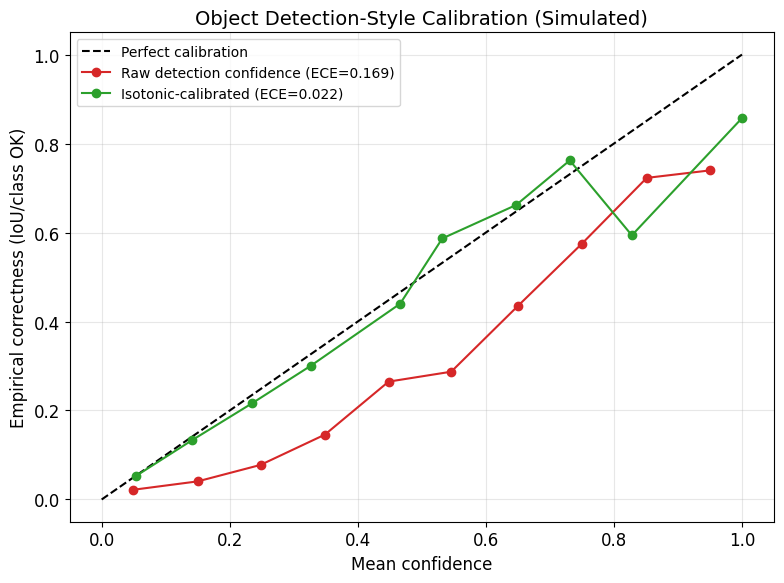


Saved: detection_reliability_isotonic.png


In [16]:
from sklearn.isotonic import IsotonicRegression

print("="*70)
print("Object Detection-Style Calibration (Simulated)")
print("="*70)

N = 4000
raw_conf = rng.uniform(0, 1, size=N)

# Underlying (unknown) probability that a detection is correct
# Simulates: low confidence -> usually wrong, high confidence -> often correct
true_p = 1/(1+np.exp(-6*(raw_conf-0.65))) * 0.9
y_corr = rng.binomial(1, true_p)

# Split for calibration
conf_train, conf_test, y_train_corr, y_test_corr = train_test_split(
    raw_conf, y_corr, test_size=0.5, random_state=0, stratify=y_corr
)

# Apply isotonic regression calibration
iso = IsotonicRegression(out_of_bounds="clip")
iso.fit(conf_train, y_train_corr)
conf_cal = iso.transform(conf_test)

ece_raw = ece_binary(conf_test, y_test_corr, 10)
ece_cal_det = ece_binary(conf_cal, y_test_corr, 10)
print(f"ECE raw: {ece_raw:.4f}, ECE calibrated: {ece_cal_det:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color='black', label='Perfect calibration')

for name, conf, color in [("Raw detection confidence", conf_test, 'tab:red'), 
                           ("Isotonic-calibrated", conf_cal, 'tab:green')]:
    frac_pos, mean_pred = calibration_curve(y_test_corr, conf, n_bins=10, strategy="uniform")
    ece = ece_binary(conf, y_test_corr, 10)
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{name} (ECE={ece:.3f})", color=color)

ax.set_xlabel("Mean confidence")
ax.set_ylabel("Empirical correctness (IoU/class OK)")
ax.set_title("Object Detection-Style Calibration (Simulated)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/detection_reliability_isotonic.png", dpi=200)
plt.show()
print("\nSaved: detection_reliability_isotonic.png")


Fast Demo: Detection-Style Calibration on Digits
Treating classifier predictions as 'detections' with confidence scores.

Number of 'detections': 360
ECE (raw): 0.0205
ECE (isotonic calibrated): 0.0300


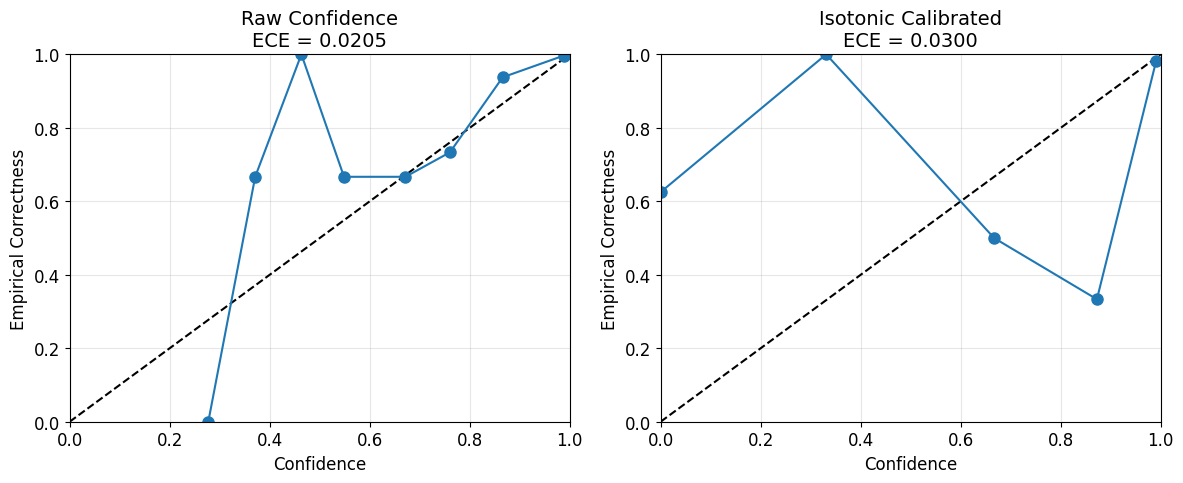

In [ ]:
# Fast real-data demo: "Detection" on MNIST/Digits
# We treat high-confidence predictions as "detections" and measure correctness

print("\n" + "="*70)
print("Fast Demo: Detection-Style Calibration on Digits")
print("="*70)
print("Treating classifier predictions as 'detections' with confidence scores.\n")

# Use the logits from Part 4
# Get all predictions with confidence > 0.5 (simulate "detected" objects)
probs_all = softmax(logits_test / 1.0, axis=1)
conf_det = probs_all.max(axis=1)
pred_det = probs_all.argmax(axis=1)
correct_det = (pred_det == y_test).astype(int)

# Apply isotonic calibration
probs_cal_all = softmax(clf.decision_function(X_cal) / 1.0, axis=1)
conf_cal_train = probs_cal_all.max(axis=1)
pred_cal_train = probs_cal_all.argmax(axis=1)
correct_cal_train = (pred_cal_train == y_cal).astype(int)

iso_det = IsotonicRegression(out_of_bounds="clip")
iso_det.fit(conf_cal_train, correct_cal_train)
conf_det_calibrated = iso_det.transform(conf_det)

ece_raw_det = ece_binary(conf_det, correct_det, 10)
ece_cal_det2 = ece_binary(conf_det_calibrated, correct_det, 10)

print(f"Number of 'detections': {len(conf_det)}")
print(f"ECE (raw): {ece_raw_det:.4f}")
print(f"ECE (isotonic calibrated): {ece_cal_det2:.4f}")

# Quick plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (conf, title) in zip(axes, [(conf_det, 'Raw Confidence'), (conf_det_calibrated, 'Isotonic Calibrated')]):
    frac_pos, mean_pred = calibration_curve(correct_det, conf, n_bins=10, strategy="uniform")
    ece_val = ece_binary(conf, correct_det, 10)
    ax.plot([0, 1], [0, 1], 'k--')
    ax.plot(mean_pred, frac_pos, 'o-', markersize=8)
    ax.set_xlabel('Confidence')
    ax.set_ylabel('Empirical Correctness')
    ax.set_title(f'{title}\nECE = {ece_val:.4f}')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

---

# Part 6: LLM Confidence Calibration

Large Language Models face unique calibration challenges:

**Sources of confidence in LLMs:**
1. **Token log-probabilities**: Direct output from the model (most reliable)
2. **Self-verbalized confidence**: Ask the model "how confident are you?" (less reliable)
3. **Consistency-based**: Sample multiple responses, confidence = agreement rate

**Defining correctness:**
- Multiple-choice QA: Exact match with correct answer
- Open-ended QA: Semantic similarity or human evaluation

Below we demonstrate with simulated data AND a fast real demo using text classification.

LLM-Style Calibration (Simulated QA)
Optimal temperature: 1.9028
ECE raw: 0.1186, ECE calibrated: 0.0485


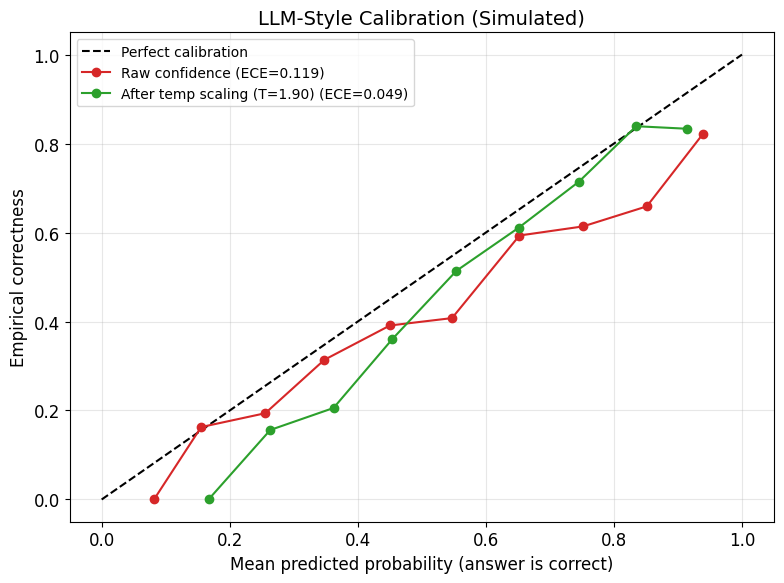


Saved: llm_reliability_temp_scaling.png


In [18]:
print("="*70)
print("LLM-Style Calibration (Simulated QA)")
print("="*70)

N = 5000
logits_llm = rng.normal(loc=1.0, scale=1.2, size=N)

# True correctness probability differs from sigmoid(logits) => miscalibration
true_p_llm = 1/(1+np.exp(-(logits_llm*0.7 - 0.4)))
y_corr_llm = rng.binomial(1, true_p_llm)

log_cal, log_test, y_cal_llm, y_test_llm = train_test_split(
    logits_llm, y_corr_llm, test_size=0.5, random_state=0, stratify=y_corr_llm
)

def nll_binary_from_logits(logits, y, T):
    p = 1/(1+np.exp(-(logits / T)))
    eps=1e-12
    return -np.mean(y*np.log(p+eps) + (1-y)*np.log(1-p+eps))

def obj_logT(logT):
    T = np.exp(logT[0])
    return nll_binary_from_logits(log_cal, y_cal_llm, T)

res = minimize(obj_logT, x0=np.array([0.0]), method="Nelder-Mead", options={"maxiter": 200})
T_llm = float(np.exp(res.x[0]))
print(f"Optimal temperature: {T_llm:.4f}")

p_raw_llm = 1/(1+np.exp(-log_test))
p_cal_llm = 1/(1+np.exp(-(log_test / T_llm)))

ece_raw_llm = ece_binary(p_raw_llm, y_test_llm, 10)
ece_cal_llm = ece_binary(p_cal_llm, y_test_llm, 10)
print(f"ECE raw: {ece_raw_llm:.4f}, ECE calibrated: {ece_cal_llm:.4f}")

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot([0, 1], [0, 1], linestyle="--", color='black', label='Perfect calibration')

for name, conf, color in [("Raw confidence", p_raw_llm, 'tab:red'), 
                           (f"After temp scaling (T={T_llm:.2f})", p_cal_llm, 'tab:green')]:
    frac_pos, mean_pred = calibration_curve(y_test_llm, conf, n_bins=10, strategy="uniform")
    ece = ece_binary(conf, y_test_llm, 10)
    ax.plot(mean_pred, frac_pos, marker="o", label=f"{name} (ECE={ece:.3f})", color=color)

ax.set_xlabel("Mean predicted probability (answer is correct)")
ax.set_ylabel("Empirical correctness")
ax.set_title("LLM-Style Calibration (Simulated)")
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
fig.tight_layout()
fig.savefig(f"{OUT_DIR}/llm_reliability_temp_scaling.png", dpi=200)
plt.show()
print("\nSaved: llm_reliability_temp_scaling.png")

In [19]:
# Fast real-data demo: Simulating LLM QA calibration
# We'll use the digits dataset and frame it as a "QA task"
# where the model's confidence in its prediction represents "LLM confidence"

print("\n" + "="*70)
print("Fast Demo: LLM-Style Calibration on Classification Task")
print("="*70)
print("Using Digits dataset as proxy for QA task")
print("- Confidence = model's probability for predicted class")
print("- Correctness = whether prediction matches true label\n")

# Use the existing digits data from Part 4
# Get predictions from the trained classifier
probs_cal_llm_demo = softmax(clf.decision_function(X_cal) / 1.0, axis=1)
probs_test_llm_demo = softmax(clf.decision_function(X_test) / 1.0, axis=1)

conf_cal_llm_demo = probs_cal_llm_demo.max(axis=1)
pred_cal_llm_demo = probs_cal_llm_demo.argmax(axis=1)
correct_cal_llm_demo = (pred_cal_llm_demo == y_cal).astype(int)

conf_test_llm_demo = probs_test_llm_demo.max(axis=1)
pred_test_llm_demo = probs_test_llm_demo.argmax(axis=1)
correct_test_llm_demo = (pred_test_llm_demo == y_test).astype(int)

print(f"Number of 'questions': {len(conf_test_llm_demo)}")
print(f"Base accuracy: {correct_test_llm_demo.mean():.4f}")


Fast Demo: LLM-Style Calibration on Classification Task
Using Digits dataset as proxy for QA task
- Confidence = model's probability for predicted class
- Correctness = whether prediction matches true label

Number of 'questions': 360
Base accuracy: 0.9639



ECE (raw): 0.0205
ECE (isotonic calibrated): 0.0300


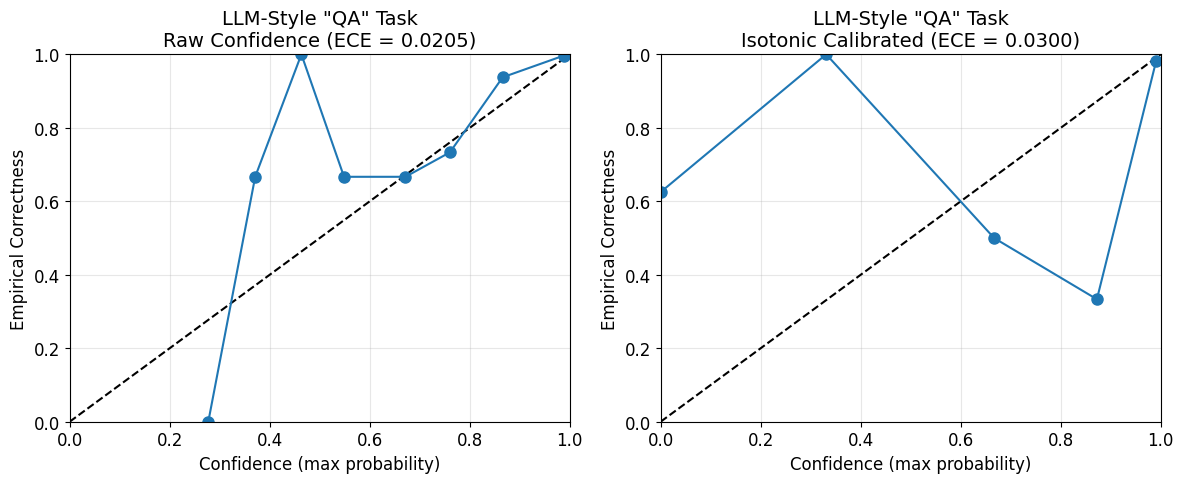


This demonstrates LLM-style calibration analysis:
- Confidence = model's max probability for its predicted answer
- Correctness = whether the prediction matched the true label


In [20]:
# Apply isotonic calibration
iso_llm_demo = IsotonicRegression(out_of_bounds="clip")
iso_llm_demo.fit(conf_cal_llm_demo, correct_cal_llm_demo)
conf_test_llm_cal_demo = iso_llm_demo.transform(conf_test_llm_demo)

ece_raw_llm_demo = ece_binary(conf_test_llm_demo, correct_test_llm_demo, 10)
ece_cal_llm_demo = ece_binary(conf_test_llm_cal_demo, correct_test_llm_demo, 10)

print(f"\nECE (raw): {ece_raw_llm_demo:.4f}")
print(f"ECE (isotonic calibrated): {ece_cal_llm_demo:.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (conf, title) in zip(axes, [(conf_test_llm_demo, 'Raw Confidence'), 
                                      (conf_test_llm_cal_demo, 'Isotonic Calibrated')]):
    frac_pos, mean_pred = calibration_curve(correct_test_llm_demo, conf, n_bins=10, strategy="uniform")
    ece_val = ece_binary(conf, correct_test_llm_demo, 10)
    ax.plot([0, 1], [0, 1], 'k--', label='Perfect calibration')
    ax.plot(mean_pred, frac_pos, 'o-', markersize=8, color='tab:blue')
    ax.set_xlabel('Confidence (max probability)')
    ax.set_ylabel('Empirical Correctness')
    ax.set_title(f'LLM-Style "QA" Task\n{title} (ECE = {ece_val:.4f})')
    ax.grid(True, alpha=0.3)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

print("\nThis demonstrates LLM-style calibration analysis:")
print("- Confidence = model's max probability for its predicted answer")
print("- Correctness = whether the prediction matched the true label")

---

# Part 7: Toy Demo - Miscalibration + Temperature Scaling (Course Slides)

This demo generates the reliability diagrams shown in the course slides.

In [21]:
# Generate toy demo for course slides
print("Generating toy demo figures for course slides...")

np.random.seed(42)
N_toy = 3000

# Generate an overconfident classifier
# True underlying probability
true_prob = np.random.beta(2, 2, N_toy)
y_toy = np.random.binomial(1, true_prob)

# Overconfident logits (exaggerated toward extremes)
logits_toy = 3.0 * (true_prob - 0.5) + np.random.normal(0, 0.3, N_toy)
p_overconf_toy = 1 / (1 + np.exp(-logits_toy))

# Split
idx_split = N_toy // 2
logits_cal_toy = logits_toy[:idx_split]
logits_test_toy = logits_toy[idx_split:]
y_cal_toy = y_toy[:idx_split]
y_test_toy = y_toy[idx_split:]

# Fit temperature
def obj_toy(logT):
    T = np.exp(logT)
    p = 1/(1+np.exp(-(logits_cal_toy / T)))
    eps = 1e-12
    return -np.mean(y_cal_toy*np.log(p+eps) + (1-y_cal_toy)*np.log(1-p+eps))

res_toy = minimize(obj_toy, x0=0, method="Nelder-Mead")
T_toy = float(np.exp(res_toy.x[0]) if hasattr(res_toy.x, "__len__") else np.exp(res_toy.x))
print(f"Learned temperature T = {T_toy:.2f}")

# Before/after probabilities
p_before = 1 / (1 + np.exp(-logits_test_toy))
p_after = 1 / (1 + np.exp(-(logits_test_toy / T_toy)))

ece_before = ece_binary(p_before, y_test_toy, 10)
ece_after = ece_binary(p_after, y_test_toy, 10)
nll_before = compute_nll(y_test_toy, p_before)
nll_after = compute_nll(y_test_toy, p_after)
brier_before = compute_brier_score(y_test_toy, p_before)
brier_after = compute_brier_score(y_test_toy, p_after)

Generating toy demo figures for course slides...
Learned temperature T = 0.83


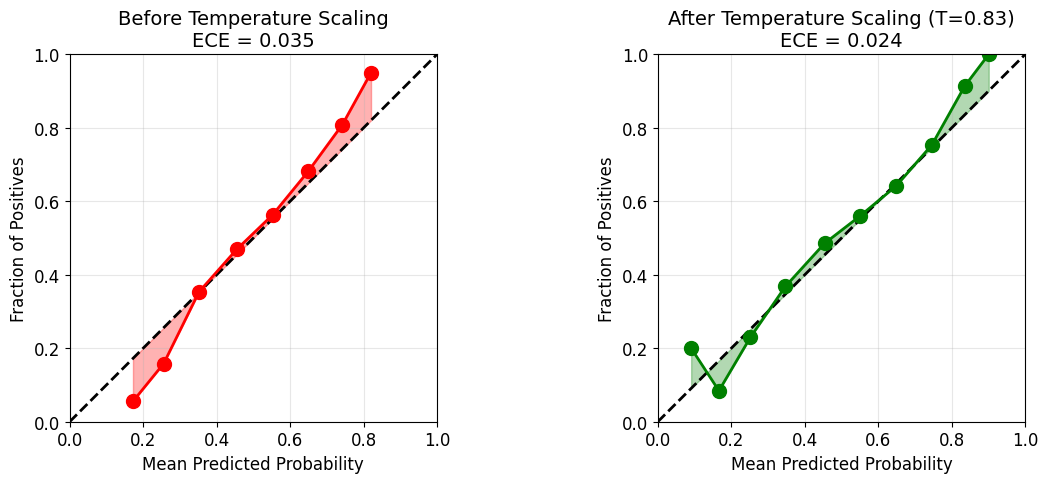

Saved: reliability_before.png, reliability_after.png


In [22]:
# Create side-by-side reliability diagrams for slides
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Before
ax = axes[0]
frac_pos_b, mean_pred_b = calibration_curve(y_test_toy, p_before, n_bins=10, strategy="uniform")
ax.plot([0, 1], [0, 1], 'k--', linewidth=2)
ax.plot(mean_pred_b, frac_pos_b, 'ro-', markersize=10, linewidth=2)
ax.fill_between(mean_pred_b, frac_pos_b, mean_pred_b, alpha=0.3, color='red')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title(f'Before Temperature Scaling\nECE = {ece_before:.3f}', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

# After
ax = axes[1]
frac_pos_a, mean_pred_a = calibration_curve(y_test_toy, p_after, n_bins=10, strategy="uniform")
ax.plot([0, 1], [0, 1], 'k--', linewidth=2)
ax.plot(mean_pred_a, frac_pos_a, 'go-', markersize=10, linewidth=2)
ax.fill_between(mean_pred_a, frac_pos_a, mean_pred_a, alpha=0.3, color='green')
ax.set_xlabel('Mean Predicted Probability', fontsize=12)
ax.set_ylabel('Fraction of Positives', fontsize=12)
ax.set_title(f'After Temperature Scaling (T={T_toy:.2f})\nECE = {ece_after:.3f}', fontsize=14)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(True, alpha=0.3)
ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/reliability_before.png', dpi=200, bbox_inches='tight')
plt.savefig(f'{OUT_DIR}/reliability_after.png', dpi=200, bbox_inches='tight')
plt.show()

print("Saved: reliability_before.png, reliability_after.png")

In [23]:
# Print metrics table for slides
print("\n" + "="*60)
print("Toy Demo Metrics (Test Set)")
print("="*60)
print(f"{'Metric':<15} {'Before':>15} {'After (Temp. scaling)':>25}")
print("-"*60)
print(f"{'NLL':<15} {nll_before:>15.3f} {nll_after:>25.3f}")
print(f"{'Brier':<15} {brier_before:>15.3f} {brier_after:>25.3f}")
print(f"{'ECE (10 bins)':<15} {ece_before:>15.3f} {ece_after:>25.3f}")
print("-"*60)
print(f"\nLearned temperature T ≈ {T_toy:.2f} (higher T softens overconfident logits)")


Toy Demo Metrics (Test Set)
Metric                   Before     After (Temp. scaling)
------------------------------------------------------------
NLL                       0.603                     0.598
Brier                     0.208                     0.206
ECE (10 bins)             0.035                     0.024
------------------------------------------------------------

Learned temperature T ≈ 0.83 (higher T softens overconfident logits)


---

# Summary: Key Takeaways

## Proper Scoring Rules
- **NLL (Log Loss)**: Penalizes confident wrong predictions heavily
- **Brier Score**: Squared error, more balanced penalty
- Both are minimized when predicted probabilities = true probabilities

## Reliability Diagrams & ECE
- Visual tool to diagnose calibration issues
- **Overconfident**: curve BELOW diagonal (predicted > actual)
- **Underconfident**: curve ABOVE diagonal (predicted < actual)
- ECE quantifies miscalibration (lower is better)

## Calibration Methods
- **Platt Scaling**: Fits sigmoid, good for SVMs
- **Isotonic Regression**: Non-parametric, flexible but needs more data
- **Temperature Scaling**: Single parameter, preserves accuracy, ideal for neural networks

## Applications
- **Image Classification**: Use confidence (max prob) vs accuracy
- **Object Detection**: Define correctness via IoU + class match
- **LLMs**: Use token logprobs or self-evaluation; selective prediction is valuable

In [24]:
print("\n" + "="*60)
print("Notebook Complete!")
print("="*60)
print("\nSaved figures:")
print("  - proper_scores_nll_brier.png")
print("  - sklearn_calibration_curve.png")
print("  - digits_temp_scaling_reliability.png")
print("  - detection_reliability_isotonic.png")
print("  - llm_reliability_temp_scaling.png")
print("  - reliability_before.png")
print("  - reliability_after.png")
print("\nKey functions you can reuse:")
print("  - compute_nll(y_true, y_prob)")
print("  - compute_brier_score(y_true, y_prob)")
print("  - ece_binary(probs, y_true, n_bins)")
print("  - compute_calibration_curve(y_true, y_prob, n_bins, strategy)")
print("  - plot_reliability_diagram(y_true, y_prob, ...)")


Notebook Complete!

Saved figures:
  - proper_scores_nll_brier.png
  - sklearn_calibration_curve.png
  - digits_temp_scaling_reliability.png
  - detection_reliability_isotonic.png
  - llm_reliability_temp_scaling.png
  - reliability_before.png
  - reliability_after.png

Key functions you can reuse:
  - compute_nll(y_true, y_prob)
  - compute_brier_score(y_true, y_prob)
  - ece_binary(probs, y_true, n_bins)
  - compute_calibration_curve(y_true, y_prob, n_bins, strategy)
  - plot_reliability_diagram(y_true, y_prob, ...)
